In [1]:
import pickle
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from jetnet.utils import EtaPhiPtE_to_cartesian, cartesian_to_EtaPhiPtE

RANDOM_SEED = 42

/Users/arjunsharma/development/s25-fermilab-research/src/venv/lib/python3.10/site-packages/coffea/nanoevents/schemas/fcc.py:5: FutureWarning: In version 2025.1.0 (target date: 2024-12-31 11:59:59-06:00), this will be an error.
To raise these warnings as errors (and get stack traces to find out where they're called), run
    import warnings
    warnings.filterwarnings("error", module="coffea.*")
after the first `import coffea` or use `@pytest.mark.filterwarnings("error:::coffea.*")` in pytest.
Issue: coffea.nanoevents.methods.vector will be removed and replaced with scikit-hep vector. Nanoevents schemas internal to coffea will be migrated. Otherwise please consider using that package!.
  from coffea.nanoevents.methods import vector


## Model investigation

In [2]:
import os
# os.system("kubectl cp as-jet-debug-pod:/mnt/data/output/2025-07-23_23:24:56.300741-gqtjets-50epochs-6layers-16steps/ downloaded_output/")

In [62]:
# OUTPUT_DIR = "downloaded_output"
OUTPUT_DIR = "out/final_out"
# OUTPUT_DIR = "out/2025-07-24_14:53:38.350078-gqtjets-2epochs-3layers-16steps"

### Did weights update?

In [63]:
model_info = torch.load(f"{OUTPUT_DIR}/models/final_model.pth", map_location=torch.device('cpu'))

In [64]:
from models.NewLEFM import JetFMGenerator

n_layers = 1 + int(list(model_info.keys())[-71].split("layers.")[-1].split(".")[0])
model = JetFMGenerator(n_layers=n_layers)
model.load_state_dict(model_info)

<All keys matched successfully>

In [65]:
initial_model = JetFMGenerator(n_layers=n_layers)
initial_model_info = torch.load(f"{OUTPUT_DIR}/models/model_initial.pth", map_location=torch.device('cpu'))
initial_model.load_state_dict(initial_model_info)

<All keys matched successfully>

In [66]:
initial_model_info

OrderedDict([('time_embedding.fc1.weight',
              tensor([[-0.1692, -0.1973,  0.1807,  ..., -0.0235, -0.0132,  0.2224],
                      [ 0.0595,  0.1159, -0.0805,  ...,  0.1931, -0.1087,  0.0519],
                      [-0.0027,  0.1160,  0.0389,  ...,  0.0641,  0.1177, -0.1659],
                      ...,
                      [ 0.2087, -0.0505, -0.0034,  ..., -0.2268, -0.1691, -0.0547],
                      [-0.1979,  0.0468, -0.0497,  ...,  0.0702, -0.1953, -0.0011],
                      [-0.1349, -0.1417, -0.1464,  ...,  0.1234,  0.1983, -0.0078]])),
             ('time_embedding.fc1.bias',
              tensor([-0.0976,  0.0827, -0.0187, -0.0291,  0.0252,  0.0978, -0.0680, -0.0842,
                       0.0776, -0.0587,  0.0402, -0.0184,  0.0344,  0.0954, -0.0633, -0.0607,
                       0.0613,  0.0068, -0.0138, -0.1098,  0.1059, -0.0047, -0.0230, -0.0513,
                      -0.0247,  0.0608, -0.0029,  0.1069, -0.0072, -0.0179,  0.0706, -0.0032])),
   

In [67]:
model_info

OrderedDict([('time_embedding.fc1.weight',
              tensor([[-0.1697, -0.1932,  0.1751,  ..., -0.0285, -0.0148,  0.2210],
                      [ 0.0538,  0.1115, -0.0783,  ...,  0.1954, -0.1042,  0.0493],
                      [-0.0058,  0.1116,  0.0440,  ...,  0.0658,  0.1204, -0.1666],
                      ...,
                      [ 0.2050, -0.0574,  0.0016,  ..., -0.2239, -0.1684, -0.0531],
                      [-0.1906,  0.0420, -0.0475,  ...,  0.0761, -0.2005, -0.0017],
                      [-0.1359, -0.1361, -0.1514,  ...,  0.1237,  0.2014, -0.0112]])),
             ('time_embedding.fc1.bias',
              tensor([-0.0975,  0.0827, -0.0187, -0.0291,  0.0252,  0.0978, -0.0679, -0.0842,
                       0.0776, -0.0587,  0.0402, -0.0184,  0.0344,  0.0954, -0.0633, -0.0606,
                       0.0613,  0.0068, -0.0138, -0.1098,  0.1059, -0.0047, -0.0230, -0.0513,
                      -0.0247,  0.0607, -0.0029,  0.1069, -0.0072, -0.0179,  0.0705, -0.0032])),
   

In [68]:
def compare_models(model_1, model_2):
    models_differ = 0
    for key_item_1, key_item_2 in zip(model_1.state_dict().items(), model_2.state_dict().items()):
        if torch.equal(key_item_1[1], key_item_2[1]):
            # print('Models match at', key_item_1[0])
            pass
        else:
            models_differ += 1
            if (key_item_1[0] == key_item_2[0]):
                print('Mismatch found at', key_item_1[0])
            else:
                raise Exception
    if models_differ == 0:
        print('Models match perfectly! :)')

compare_models(model, initial_model)

Mismatch found at time_embedding.fc1.weight
Mismatch found at time_embedding.fc1.bias
Mismatch found at time_embedding.fc2.weight
Mismatch found at time_embedding.fc2.bias
Mismatch found at global_init.0.weight
Mismatch found at global_init.0.bias
Mismatch found at global_init.1.weight
Mismatch found at global_init.1.bias
Mismatch found at global_init.1.running_mean
Mismatch found at global_init.1.running_var
Mismatch found at global_init.1.num_batches_tracked
Mismatch found at le_layers.0.alpha
Mismatch found at le_layers.0.beta
Mismatch found at le_layers.0.gamma
Mismatch found at le_layers.0.phi_e.0.weight
Mismatch found at le_layers.0.phi_e.0.bias
Mismatch found at le_layers.0.phi_e.1.weight
Mismatch found at le_layers.0.phi_e.1.bias
Mismatch found at le_layers.0.phi_e.1.running_mean
Mismatch found at le_layers.0.phi_e.1.running_var
Mismatch found at le_layers.0.phi_e.1.num_batches_tracked
Mismatch found at le_layers.0.phi_e.3.weight
Mismatch found at le_layers.0.phi_e.3.bias
Misma

## Load test data

In [69]:
with open(f"{OUTPUT_DIR}/gen/x_test.pkl", "rb") as f:
    X_test = pickle.load(f)

In [70]:
jet_eta = (X_test[:][1][:, 0]).unsqueeze(1)
jet_phi_vals = (2 * torch.pi) * torch.rand(len(X_test)).unsqueeze(1)
jet_pt_ec = X_test[:][1][:, 1:3]
jet_features = torch.concat([jet_eta, jet_phi_vals, jet_pt_ec], dim=-1)
eta_rel, phi_rel, pt_rel = torch.unbind(X_test[:][0][:, :, :3], axis=-1)
Eta, Phi, Pt, _ = torch.unbind(jet_features, axis=-1)

pt = pt_rel * Pt.unsqueeze(1)
eta = eta_rel + Eta.unsqueeze(1)
phi = phi_rel + Phi.unsqueeze(1)
p0 = pt * torch.cosh(eta)

test_features_absolute = torch.stack([eta, phi, pt, p0], dim=-1)

Text(0.5, 0.98, 'Test Features Distribution')

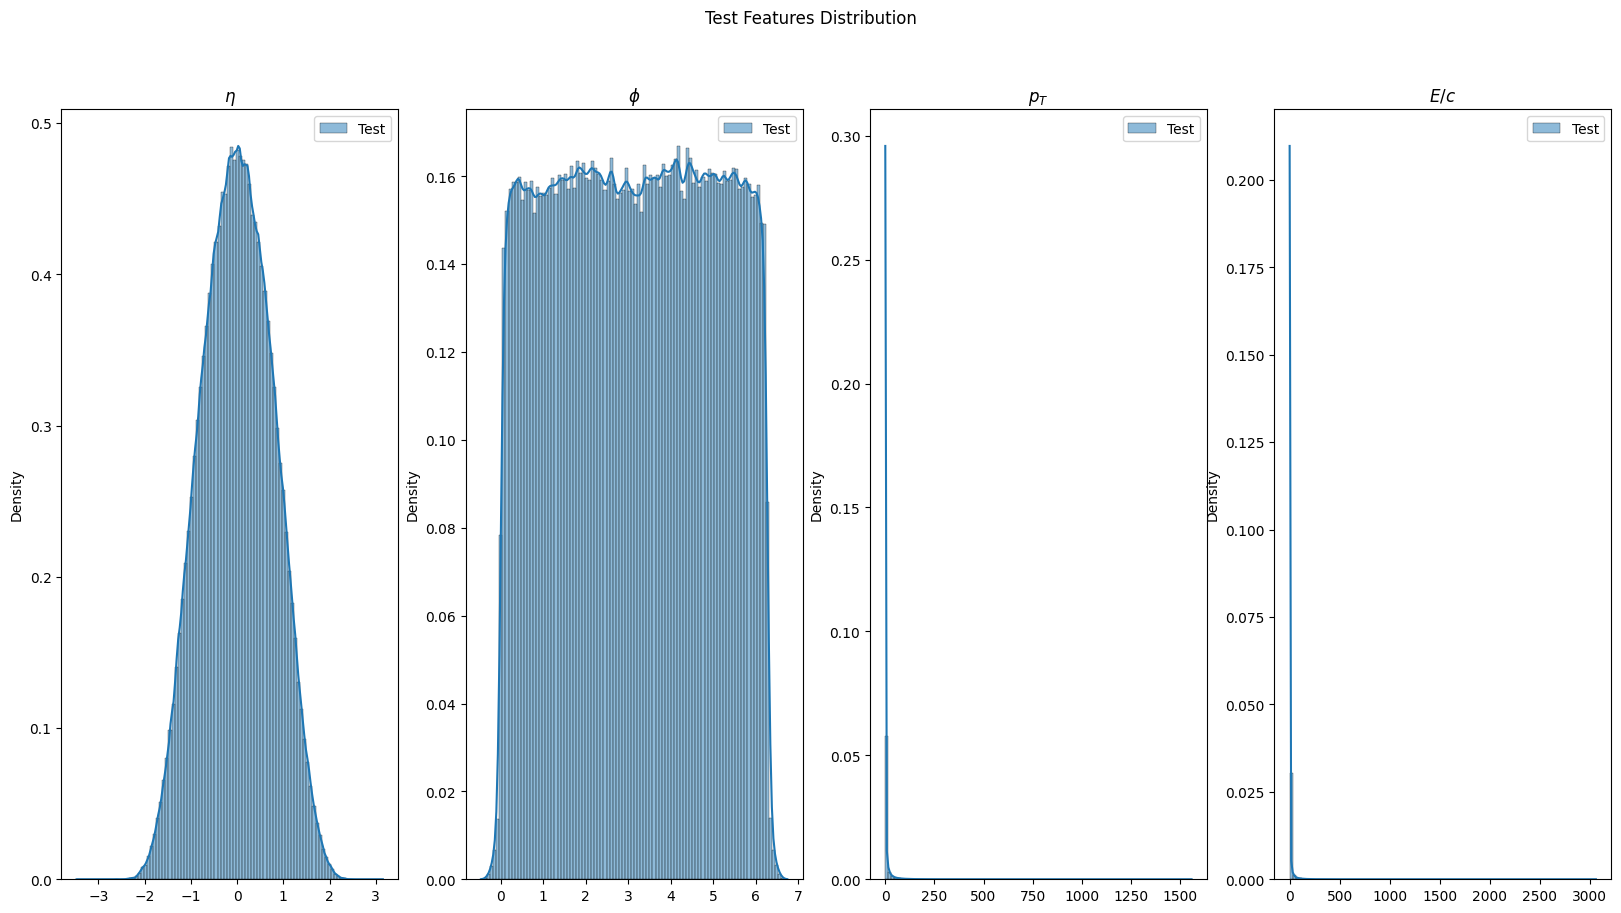

In [71]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features = [r"$\eta$", r"$\phi$", r"$p_T$", r"$E/c$"]
for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        test_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Test"
    )
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Test Features Distribution")

In [72]:
test_features_cartesian = EtaPhiPtE_to_cartesian(test_features_absolute)

Text(0.5, 0.98, 'Test Features Distribution')

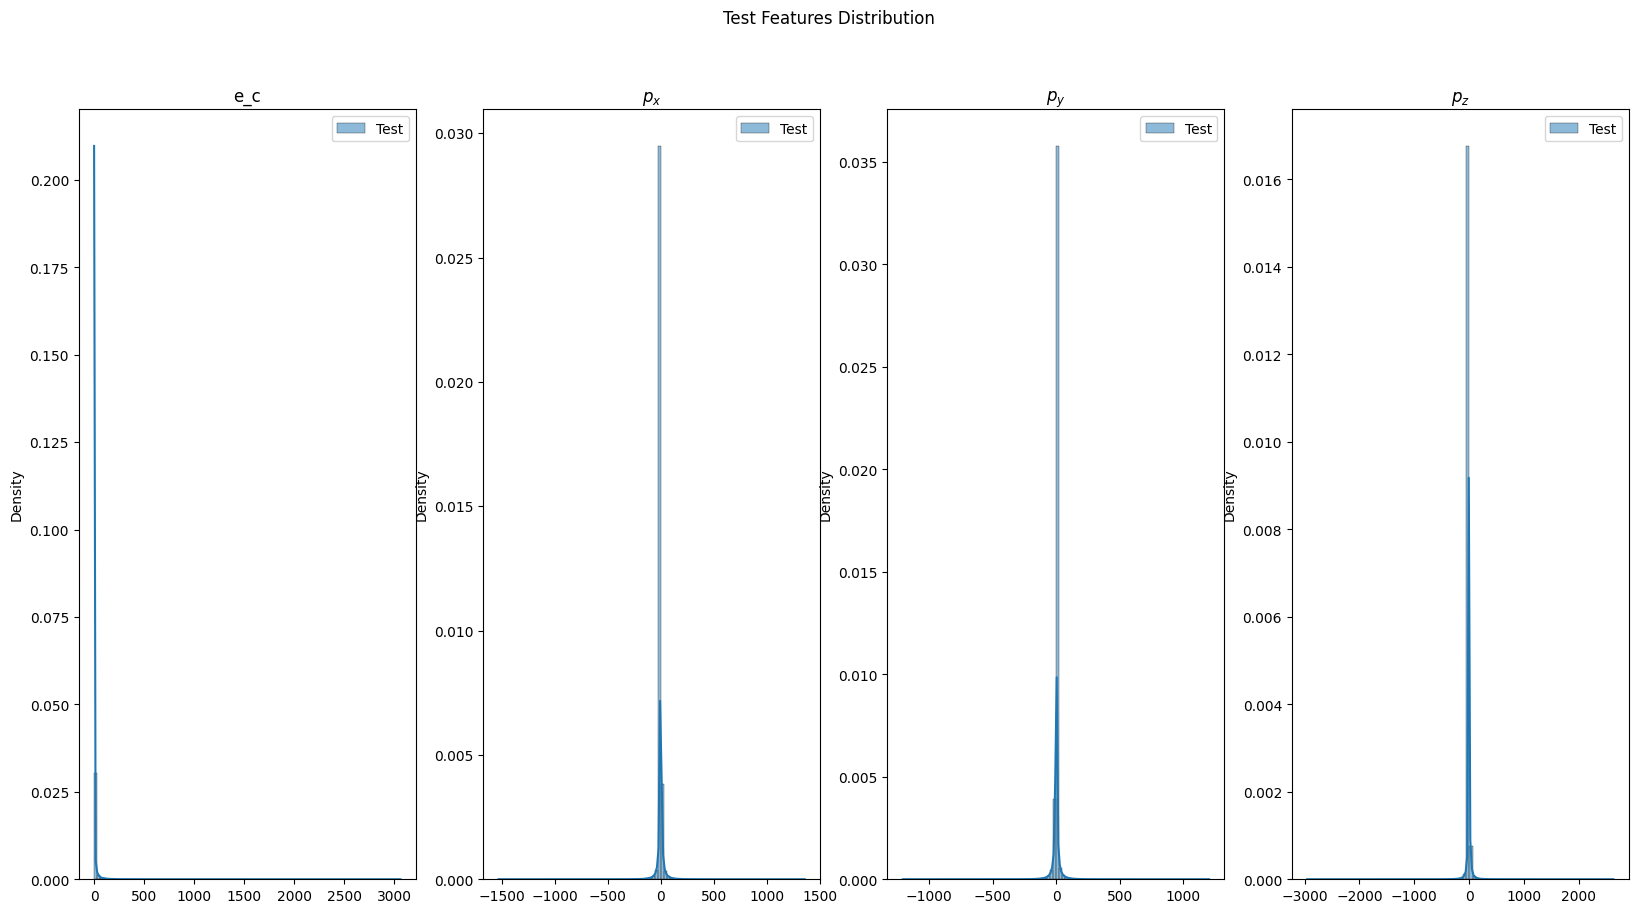

In [73]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features = [r"e_c", r"$p_x$", r"$p_y$", r"$p_z$"]
 
for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        test_features_cartesian[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Test"
    )
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Test Features Distribution")

## Load output

In [74]:
scale_factor = open(f"{OUTPUT_DIR}/logs/final_scale.txt", "r").readline().strip()
scale_factor = float(scale_factor)
scale_factor

26.903125762939453

In [76]:
# os.system(("kubectl cp as-jet-debug-pod:/mnt/data/src/out/ downloaded_output/gen/samples/"))

all_samples = []
for samples in os.scandir(f"{OUTPUT_DIR}/gen/samples"):
    if samples.is_file() and samples.name.endswith(".pt"):
        with open(samples, "rb") as f:
            all_samples.append(torch.load(f, map_location=torch.device('cpu')))

gen_features_cartesian = torch.cat(all_samples, dim=0)

# gen_features_cartesian = torch.load(f"{OUTPUT_DIR}/gen/samples_cartesian.pt", map_location=torch.device('cpu'))

In [77]:
# find nan values in the generated features
torch.isnan(gen_features_cartesian[:, :, 0])
# drop rows with nan values
gen_features_cartesian_filtered = gen_features_cartesian[~torch.isnan(gen_features_cartesian[:, :, 0]).any(dim=1)]
gen_features_cartesian_filtered.shape

torch.Size([500, 150, 4])

torch.Size([500, 150, 4])


Text(0.5, 0.98, 'Generated Features Distribution')

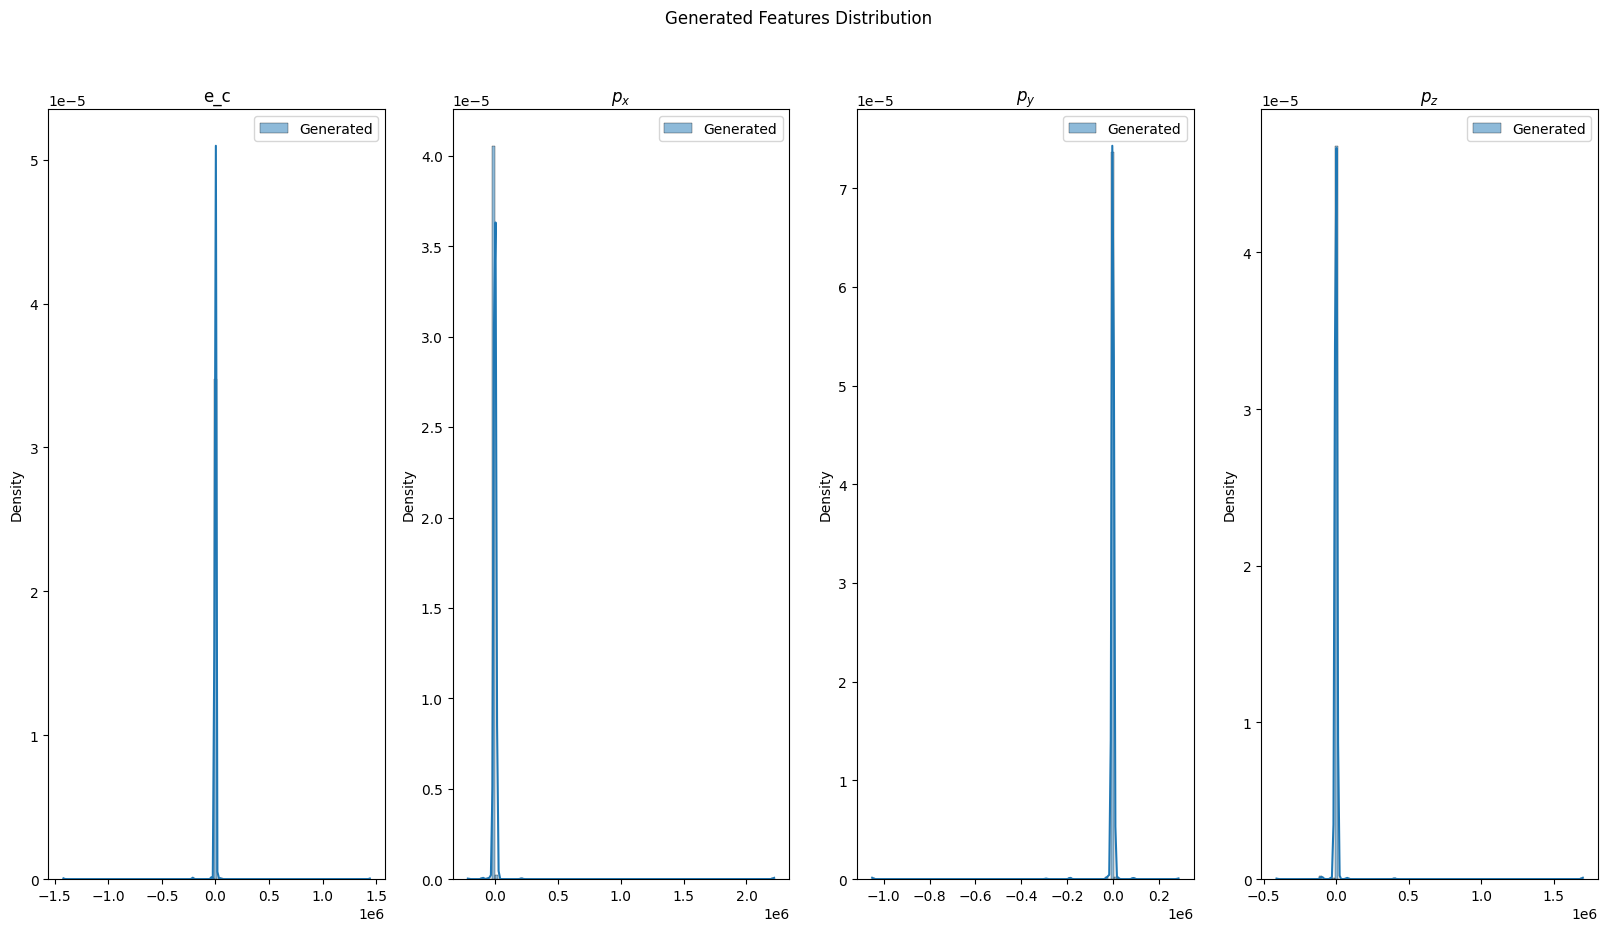

In [78]:
print(gen_features_cartesian.shape)


fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features = [r"e_c", r"$p_x$", r"$p_y$", r"$p_z$"]
 
for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        gen_features_cartesian_filtered[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Generated Features Distribution")

In [ ]:
gen_features_cartesian.shape

torch.Size([500, 150, 4])

In [ ]:
[torch.max(gen_features_cartesian[:, :, i]) for i in range(4)]

[tensor(nan), tensor(nan), tensor(nan), tensor(nan)]

In [ ]:
gen_features_absolute = cartesian_to_EtaPhiPtE(gen_features_cartesian)
gen_features_absolute[:, :, 1] += np.pi

Text(0.5, 0.98, 'Generated Features Distribution')

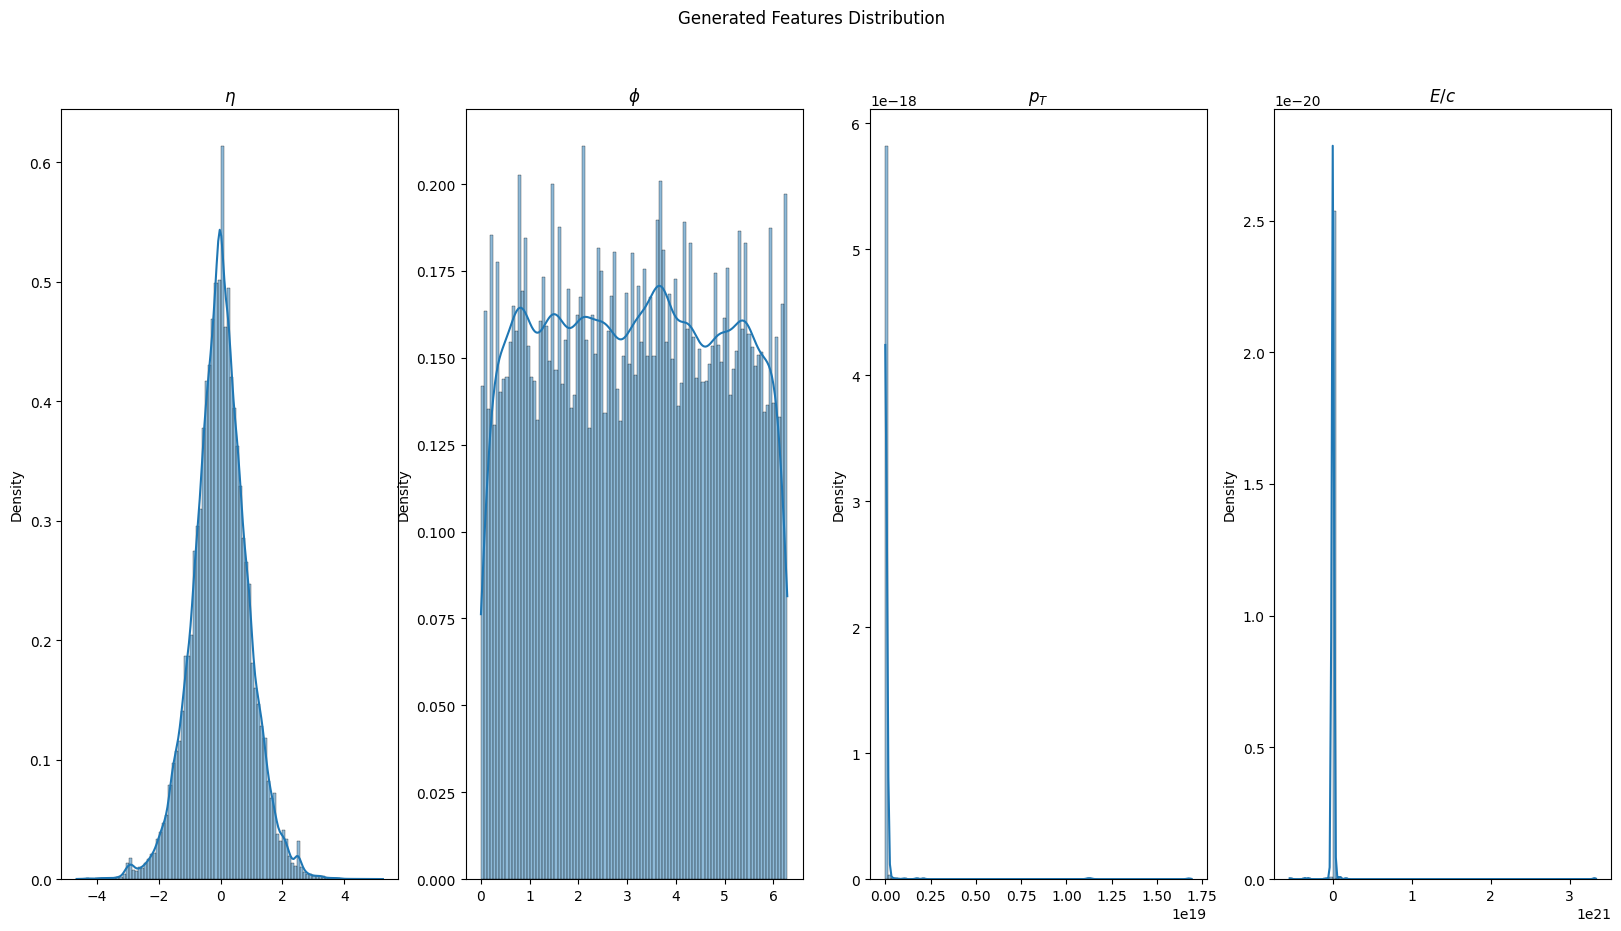

In [21]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features = [r"$\eta$", r"$\phi$", r"$p_T$", r"$E/c$"]

for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        gen_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    ax.set_title(feature)
plt.suptitle("Generated Features Distribution")

## Evaluate generated samples

### Plots

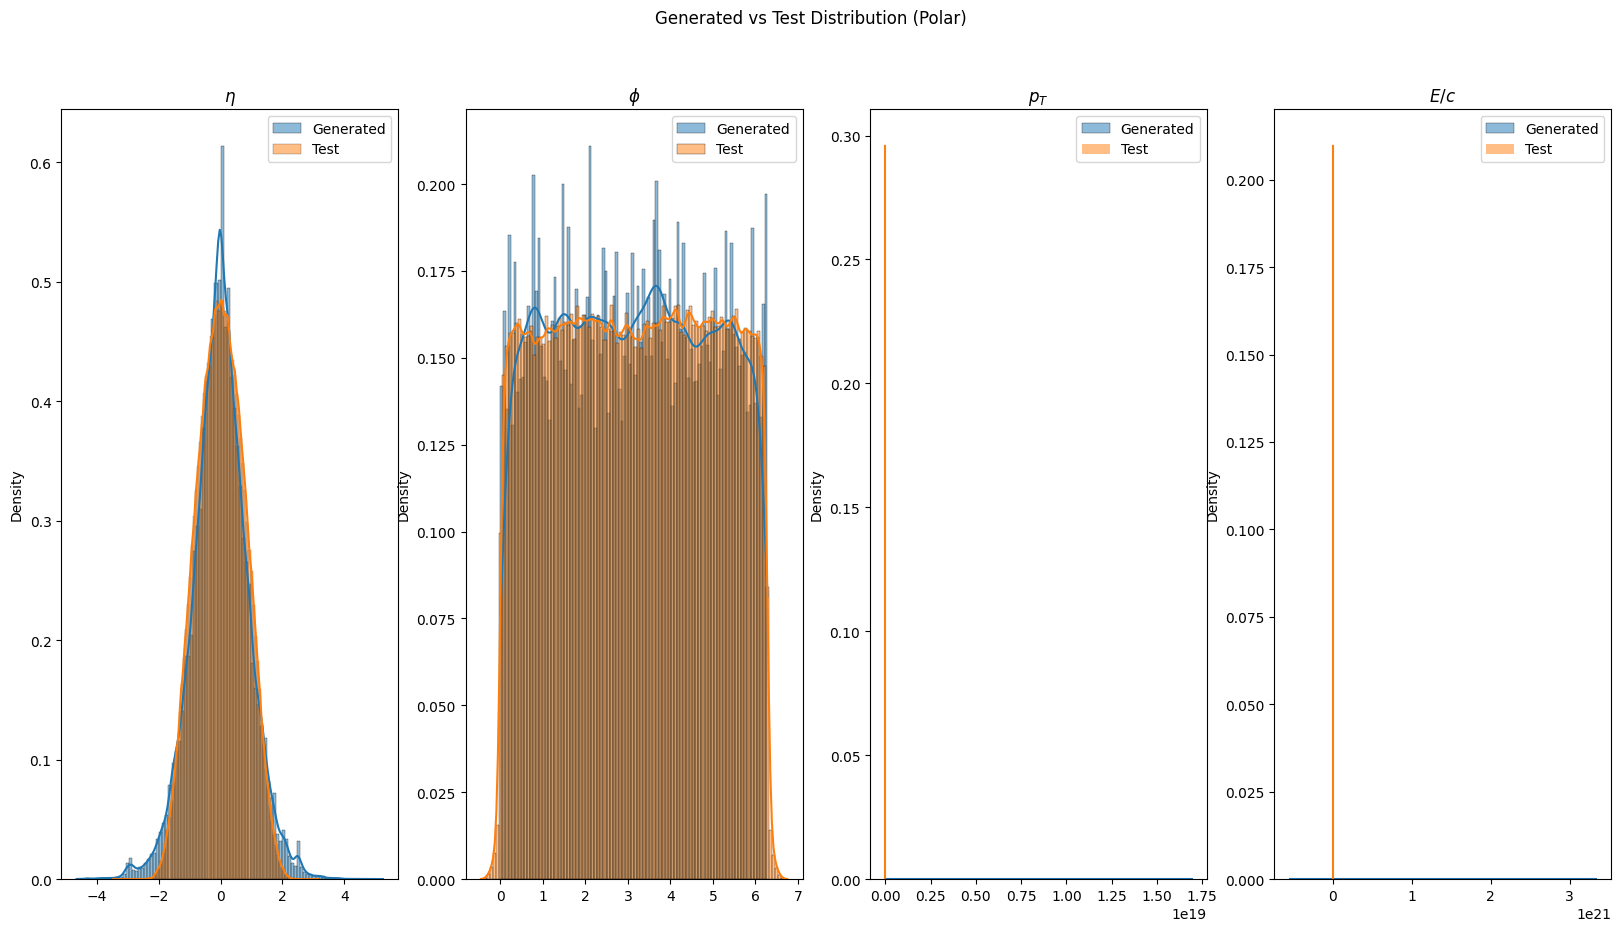

In [22]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
    
for i, feature in enumerate(features):
    ax = axs[i]
    sns.histplot(
        gen_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    sns.histplot(
        test_features_absolute[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Test"
    )
    ax.set_title(feature)
    ax.legend()

plt.suptitle("Generated vs Test Distribution (Polar)")
plt.savefig(f"gen/figs/generated_vs_test_distribution_polar.png")

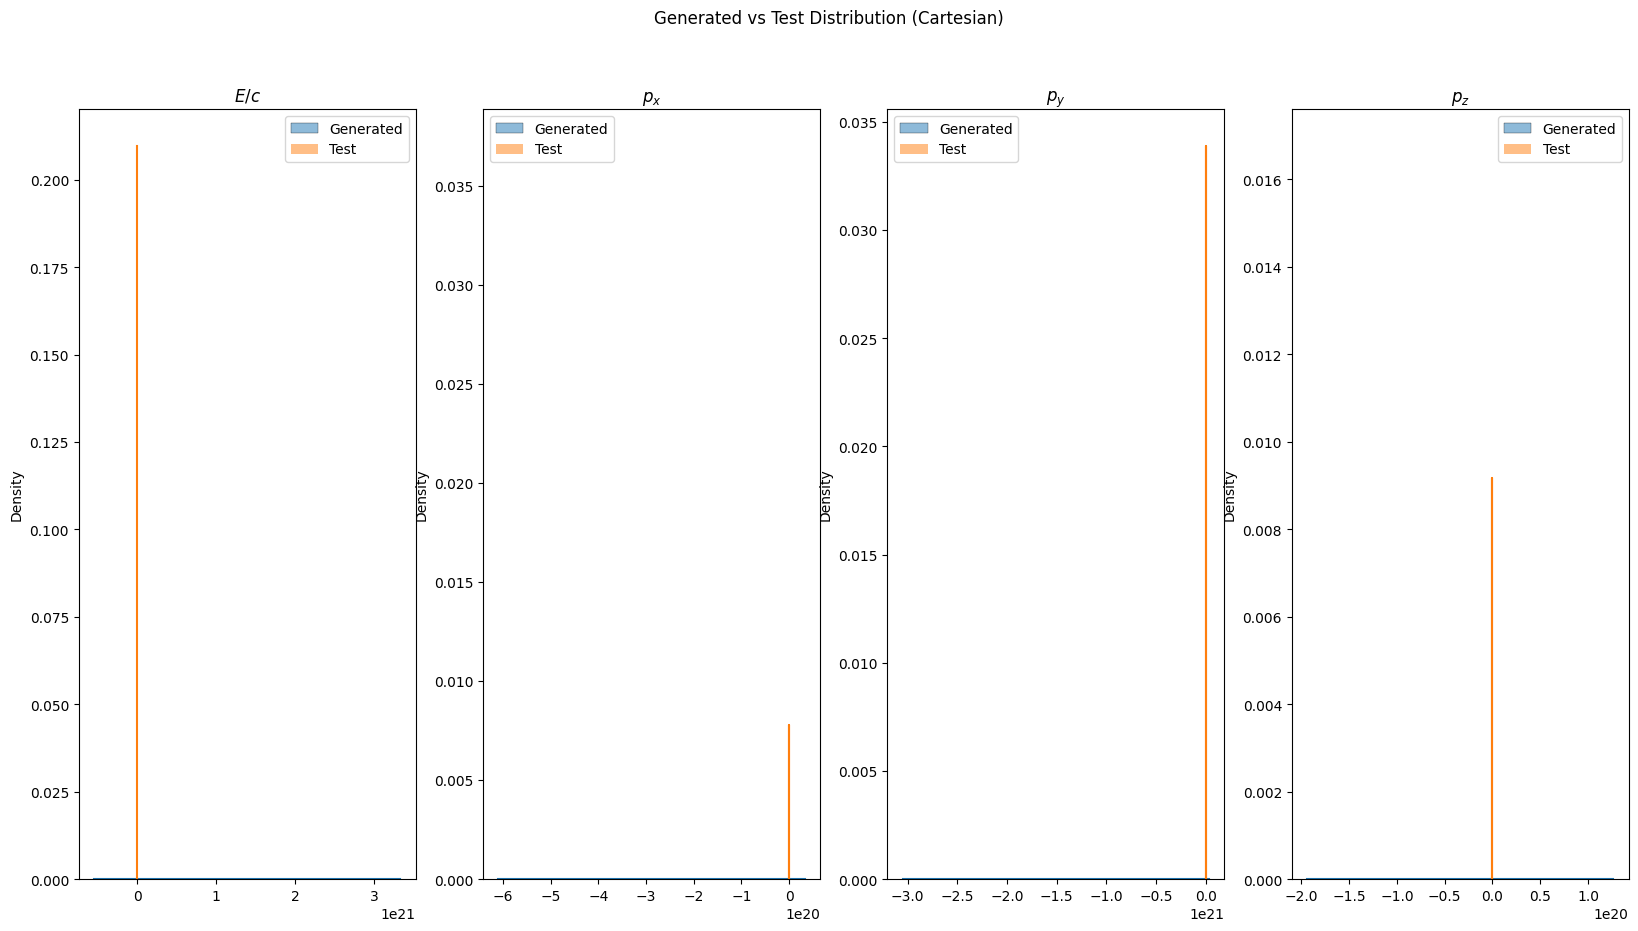

In [23]:
fig, axs = plt.subplots(1, 4, figsize=(20, 10))
features_cartesian = [r"$E/c$", r"$p_x$", r"$p_y$", r"$p_z$"]
for i, feature in enumerate(features_cartesian):
    ax = axs[i]
    sns.histplot(
        gen_features_cartesian[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Generated"
    )
    sns.histplot(
        test_features_cartesian[:, :, i].flatten().numpy(),
        bins=100,
        ax=ax,
        stat="density",
        kde=True,
        label="Test"
    )
    ax.set_title(feature)
    ax.legend()
plt.suptitle("Generated vs Test Distribution (Cartesian)")
plt.savefig(f"gen/figs/generated_vs_test_distribution_cartesian.png")

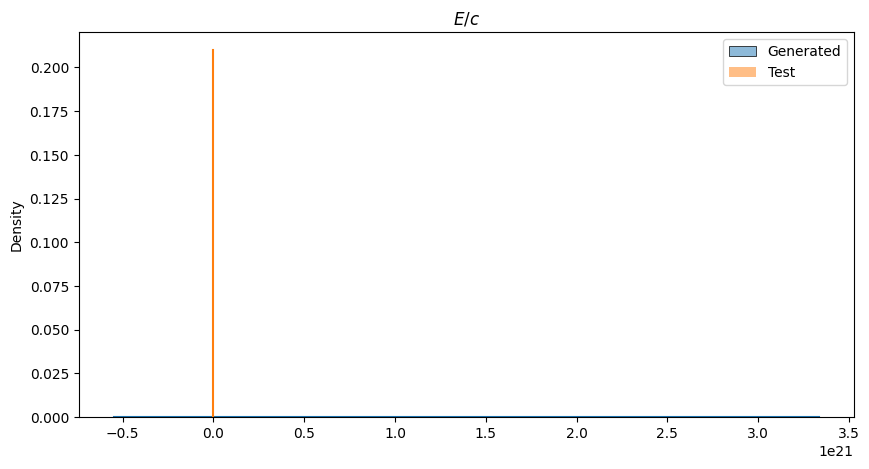

In [24]:
# Just plot e/c
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(
    gen_features_cartesian[:, :, 0].flatten().numpy(),
    bins=100,
    ax=ax,
    stat="density",
    kde=True,
    label="Generated"
)
sns.histplot(
    test_features_cartesian[:, :, 0].flatten().numpy(),
    bins=100,
    ax=ax,
    stat="density",
    kde=True,
    label="Test"
)
ax.set_title(r"$E/c$")
ax.legend()

### Metrics

In [25]:
import jetnet.evaluation as jetnet_eval
eval_info = {}

In [26]:
from jetnet.utils import EtaPhiPtE_to_relEtaPhiPt

test_features_relative = EtaPhiPtE_to_relEtaPhiPt(test_features_absolute)
gen_features_relative = EtaPhiPtE_to_relEtaPhiPt(gen_features_absolute)

In [27]:
# Has to be in order [eta, phi, pt]. Drop e/c for MMD
eval_info["cov_mmd"] = jetnet_eval.cov_mmd(
    real_jets=test_features_relative[:, :, :3],
    gen_jets=gen_features_relative[:, :, :3]
)
eval_info["cov_mmd"]

AssertionError: particle pTs must all be >= 0 for EMD calculation

In [ ]:
NUM_PARTICLE_FEATURES = 4
eval_info["fpd"] = jetnet_eval.fpd(
    real_features=test_features_relative.reshape((-1, NUM_PARTICLE_FEATURES)),
    gen_features=gen_features_relative.reshape((-1, NUM_PARTICLE_FEATURES)),
    seed=RANDOM_SEED
)
eval_info["fpd"]

In [ ]:
jets1 = gen_features_relative
jets2 = test_features_relative
eval_info["w1efp"] = jetnet_eval.w1efp(
    jets1=jets1,
    jets2=jets2,
)
eval_info["w1m"] = jetnet_eval.w1m(
    jets1=jets1,
    jets2=jets2,
)
eval_info["w1p"] = jetnet_eval.w1p(
    jets1=jets1,
    jets2=jets2,
)
eval_info["w1efp"], eval_info["w1m"], eval_info["w1p"]

In [ ]:
eval_info["fpnd_g"] = jetnet_eval.fpnd(
    jets=gen_features_relative[:, :, :3],
    jet_type="g",
    use_tqdm=False
)
eval_info["fpnd_g"]

In [ ]:
fpnd_t = jetnet_eval.fpnd(
    jets=test_features_relative[:, :, :3],
    jet_type="g"
)
fpnd_t